### Download dataset from kaggle


In [1]:
! pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

# Upload kaggle.json using kaggle API

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"zhengsiah","key":"f1c00c8d91e861dcd71b4a8f9cfa01e7"}'}

In [3]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download "vipoooool/new-plant-diseases-dataset"


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.68G/2.70G [01:51<00:03, 6.45MB/s]
100% 2.70G/2.70G [01:51<00:00, 25.9MB/s]


In [5]:
!mkdir dataset
!unzip new-plant-diseases-dataset.zip -d dataset/

Streaming output truncated to the last 5000 lines.
  inflating: dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflating: da

In [6]:
# Remove duplicate directory
!rm -r "/content/dataset/new plant diseases dataset(augmented)"


### Setup

In [7]:
# load an image and to see information


### Build the model according to the paper

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# These settings are used to be trained in google colab T4 GPU environment
BATCH_SIZE = 8 #16
IMG_SIZE = (256, 256)
RESIZED_IMG_SIZE = (96, 96)
LEARNING_RATE=5e-5 # 5e-5
USE_SMALL_DATASET = True # change to false if you want to use whole dataset
SMALL_DATASET_SIZE= 625 # 625
LOSS = tf.keras.losses.SparseCategoricalCrossentropy()
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
METRICS = ['accuracy', ]
EPOCHS = 100

TRAIN_DIR = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
TEST_DIR = "/content/dataset/test/test"

# Verify that colab is using GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Get file paths of every img in TEST_DIR
file_path = [os.path.join(TEST_DIR, f) for f in os.listdir(TEST_DIR) if f.endswith(".JPG")]

# extract labels from filenames
class_names = sorted(list(set([f.split('/')[-1].split('.')[0].rstrip('0123456789') for f in file_path])))

class_to_index = {name: idx for idx, name in enumerate(class_names)}
print(class_to_index)
test_labels = [class_to_index[f.split('/')[-1].split('.')[0].rstrip('0123456789')] for f in file_path]

print(test_labels)

{'AppleCedarRust': 0, 'AppleScab': 1, 'CornCommonRust': 2, 'PotatoEarlyBlight': 3, 'PotatoHealthy': 4, 'TomatoEarlyBlight': 5, 'TomatoHealthy': 6, 'TomatoYellowCurlVirus': 7}
[3, 0, 6, 3, 3, 7, 3, 6, 6, 1, 1, 0, 2, 5, 5, 2, 5, 0, 2, 0, 3, 7, 7, 5, 5, 6, 4, 7, 5, 7, 4, 7, 1]


In [3]:
# Setup train and test dataset
train_ds = tf.keras.utils.image_dataset_from_directory(directory=TRAIN_DIR,
                                                       labels="inferred",
                                                       seed=123,
                                                       image_size=(IMG_SIZE),
                                                       batch_size=BATCH_SIZE,
                                                       shuffle=True)

val_ds = tf.keras.utils.image_dataset_from_directory(directory=VAL_DIR,
                                                     labels="inferred",
                                                     seed=123,
                                                     image_size=(IMG_SIZE),
                                                     batch_size=BATCH_SIZE,
                                                     )

#
test_ds = tf.keras.utils.image_dataset_from_directory(directory=TEST_DIR,
                                                      labels=test_labels)

# Use mixed precision to reduce size of dataset
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found 33 files belonging to 8 classes.


In [4]:
# Model: Tiny-LiteNet, size of 1.2MB
num_classes = len(train_ds.class_names)

# Normalize the image from [0, 255] -> [0, 1]
# resize image from (256, 256) -> (96, 96) The paper uses (244,244)
normalize_layer = tf.keras.layers.Rescaling(1./255)
resize_layer = tf.keras.layers.Resizing(RESIZED_IMG_SIZE[0], RESIZED_IMG_SIZE[1])

# Configure dataset for performance
# Dataset.cache ensures dataset doesnt become bottleneck while training the model. Dataset.prefetch overlaps data preprocessing and model execution
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [5]:
if USE_SMALL_DATASET:
  # Use smaller dataset to avoid crashing in google colab
  train_ds = train_ds.take(SMALL_DATASET_SIZE)
  val_ds = val_ds.take(SMALL_DATASET_SIZE)


# Show dataset size (in batches)
print(f"train_ds size: {tf.data.experimental.cardinality(train_ds)}")
print(f"val_ds size: {tf.data.experimental.cardinality(val_ds)}")
print(f"test_ds size: {tf.data.experimental.cardinality(test_ds)}")

train_ds size: 625
val_ds size: 625
test_ds size: 2


In [6]:
# On more powerful devices, uncomment depthwise blocks to use full architecture

def se_depthwise_block():
  return [
      tf.keras.layers.DepthwiseConv2D(kernel_size=3),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Activation('relu'),
      tf.keras.layers.SeparableConv2D(filters=128, kernel_size=1),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Activation('relu'),
      tf.keras.layers.MaxPool2D()
  ]


model = tf.keras.Sequential([
    normalize_layer,
    resize_layer,
    *se_depthwise_block(),
    *se_depthwise_block(),
    *se_depthwise_block(),
    #*se_depthwise_block(),
    #*se_depthwise_block(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')# softmax for multiclass classification
])
model

<Sequential name=sequential, built=False>

In [7]:
# try load the dataset using GPU, for some reason it crashes when using CPU
with tf.device('/device:GPU:0'):
  train_ds = train_ds.map(lambda x, y: (x, y))

In [8]:
# clear prev session before building model
tf.keras.backend.clear_session()

# compile model
model.compile(optimizer=OPTIMIZER,
              loss=LOSS,
              metrics=METRICS)

In [9]:
# Train the model
history = model.fit(train_ds,
          validation_data=val_ds,
          batch_size=BATCH_SIZE,
          epochs=EPOCHS)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 29ms/step - accuracy: 0.0593 - loss: 3.5582 - val_accuracy: 0.0342 - val_loss: 3.6263
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1772 - loss: 3.1238 - val_accuracy: 0.2892 - val_loss: 2.7506
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.2423 - loss: 2.8259 - val_accuracy: 0.3394 - val_loss: 2.4890
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2945 - loss: 2.6177 - val_accuracy: 0.3720 - val_loss: 2.2985
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3301 - loss: 2.4754 - val_accuracy: 0.4162 - val_loss: 2.1519
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3401 - loss: 2.3448 - val_accuracy: 0.4566 - val_loss: 2.0245
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3698 - loss: 2.2279 - val_accuracy: 0.4864 - val_loss: 1.9252
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3945 - loss: 2

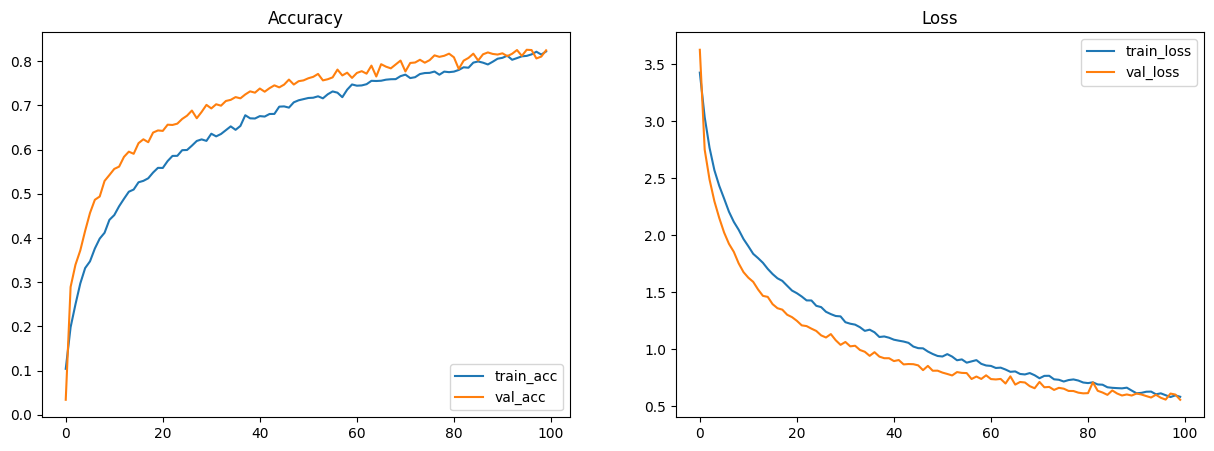

In [21]:
# Plot graph of train and validation to see if overfitting/underfitting
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = list(range(len(train_loss)))

fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(epochs, train_acc, label='train_acc')
ax[0].plot(epochs, val_acc, label='val_acc')
ax[0].set_title('Accuracy')
ax[0].legend(loc="lower right")

ax[1].plot(epochs, train_loss, label='train_loss')
ax[1].plot(epochs, val_loss, label='val_loss')
ax[1].set_title('Loss')
ax[1].legend(loc="upper right")


In [28]:
# save the model
try:
  print("Saving model...")
  model.save("modified-tiny-lite-net.keras")

except AttributeError:
  print("Loading model...")
  model = tf.keras.models.load_model("modified-tiny-lite-net.keras")

Saving model...


In [34]:
# create converter and optimize it for tf lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert to tf lite model
tflite_model = converter.convert()

# give size of model (Mb)
size_bytes = len(tflite_model)
size_kb = size_bytes / 1024
size_mb = size_kb / 1024


Saved artifact at '/tmp/tmp2nh6hw2v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float16, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float16, name=None)
Captures:
  138121086233552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086236816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086237200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086237392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086237008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086236240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086236432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086237776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086236624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138121086238352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13812108623585

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["Mul:", "sequential_1/rescaling_1/mul@__inference_function_671964"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_672147"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.Mul' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["Mul:", "sequential_1/rescaling_1/mul@__inference_function_671964"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_672147"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): see current operation: %36 = "tf.Mul"(%arg0, %35) {device = ""} : (tensor<?x256x256x3xf16>, tensor<f16>) -> tensor<?x256x256x3xf16>
<unknown>:0: note: loc(callsite(callsite(fused["Mul:", "sequential_1/rescaling_1/mul@__infe

In [ ]:
# Test model with test set
result = model.evaluate(test_ds)


In [ ]:
predictions = model.predict(test_ds)

In [ ]:
print(predictions.shape)

In [ ]:
# See for outselves visually how the model is doing